# Modern Subscription Retention Analysis
## Censoring-aware cohort reporting and discrete-time survival modeling

This notebook modernizes the original **Subscribe Retention** project while preserving its business questions:

1. How is the subscription cohort retaining over time?
2. How does retention differ by monthly price?
3. What percentage of each price group may remain after 12 billing cycles?
4. How are country and acquisition source associated with retention?
5. How can these findings support revenue decisions?

### Main methodological change

The original notebook fit separate linear regressions to eight aggregate retention points. This version treats retention as a **time-to-event problem with right censoring**:

- inactive subscribers have an observed churn event;
- active subscribers have not churned yet, so their eventual lifetime is unknown;
- observed retention is estimated nonparametrically;
- future retention is modeled with a **discrete-time complementary log-log hazard model**;
- model selection uses a validation set rather than in-sample error;
- the test set is reserved for final probability and retention-curve evaluation;
- months beyond the observed period are clearly labeled as extrapolation.

The model remains linear and interpretable on the transformed hazard scale, so XGBoost is not necessary for this dataset.

## Why the old regression approach needed updating

The earlier workflow was useful for exploration, but it had important limitations:

- It created only eight observations per price point and then fit a flexible regression to those same observations.
- Its reported MAE was training error, not out-of-sample validation error.
- Ordinary regression does not naturally understand active subscribers as right-censored observations.
- A polynomial can produce retention forecasts that rise, become negative, or exceed 100%.
- Separate price models do not jointly adjust for country and acquisition-source mix.
- Forecast uncertainty and calibration were not evaluated.
- Country and source comparisons were descriptive but not adjusted for other observed factors.

The survival workflow below preserves retention probabilities within `[0, 1]`, keeps survival curves monotonic, and explicitly separates observed results from model-based extrapolation.

### Main improvements

- Replaced the three separate linear regressions with a **discrete-time survival model** using a binomial generalized linear model and complementary log-log link.
- Correctly treats currently active subscribers as **right-censored**, rather than assuming their final subscription lifetime is already known.
- Adds Kaplan–Meier-style observed retention estimates with confidence intervals.
- Defines churn timing consistently: a user with four billing cycles retained through cycle four and churned afterward.
- Uses user-level 70% training, 15% validation, and 15% test splits.
- Selects the tenure-curve specification using validation Brier scores and probability loss.
- Compares linear, log-linear, quadratic, and price-by-tenure interaction specifications.
- Includes a time-only baseline to verify whether price, country, and source add predictive value.
- Evaluates:
    - grouped churn-hazard log loss;
    - retention Brier scores at multiple horizons;
    - observed-versus-predicted retention curves;
    - last-observed-month calibration.
- Reports adjusted price, country, and acquisition-source hazard multipliers with confidence intervals.
- Produces standardized price comparisons using the same country and source mix for each price.
- Forecasts retention through month 12 with model-based uncertainty bands.
- Separates observed months from extrapolated months visually.
- Calculates expected 12-month paid cycles and subscription revenue per acquired subscriber.
- Adds country and source opportunity tables.
- Saves the fitted model, metadata, coefficients, forecasts, and test curves.
- Includes a reusable function for scoring future subscriber profiles.
- Documents causal limitations, extrapolation risk, and recommended experiments.

The old notebook fitted flexible regressions to only eight aggregate retention observations per price and calculated MAE on those same fitted observations before extrapolating to month 12. The replacement instead models monthly conditional churn probabilities with a binomial complementary log-log GLM, which statsmodels supports as a standard GLM family/link combination. (StatsModels) Probability quality is assessed with Brier scores and calibration analysis rather than only curve-fitting error. (Scikit-learn)

I successfully executed all **82 cells** against a synthetic 30,000-subscriber dataset matching the original schema. The real `subscription.csv` was not available, so the delivered notebook is clean and unexecuted; running it with the real CSV will produce the final business results. The GitHub repository was not modified.

## 0. Environment and reproducibility

In [3]:
# Run only when your environment needs the packages, then restart the kernel.
# %pip install -q "pandas>=2.2" "numpy>=2.0" "matplotlib>=3.8" \
#     "scikit-learn>=1.5" "statsmodels>=0.14.4" "scipy>=1.12" "nbformat>=5.9"

In [4]:
from __future__ import annotations

import json
import math
import os
import platform
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
import statsmodels
import statsmodels.api as sm

from scipy.stats import norm
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print({
    "python": platform.python_version(),
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "scipy": scipy.__version__,
    "scikit_learn": sklearn.__version__,
    "statsmodels": statsmodels.__version__,
})

{'python': '3.12.5', 'pandas': '2.2.2', 'numpy': '2.1.0', 'scipy': '1.17.1', 'scikit_learn': '1.8.0', 'statsmodels': '0.14.6'}


## 1. Configuration

In [5]:
DATA_PATH = Path(os.getenv("SUBSCRIPTION_DATA_PATH", "subscription.csv"))
OUTPUT_DIR = Path("artifacts")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FORECAST_HORIZON = 12
VALIDATION_SIZE = 0.15
TEST_SIZE = 0.15
N_PARAMETER_SIMULATIONS = 300

REQUIRED_COLUMNS = [
    "user_id",
    "subscription_signup_date",
    "subscription_monthly_cost",
    "country",
    "source",
    "billing_cycles",
    "is_active",
]

CATEGORICAL_COLUMNS = [
    "subscription_monthly_cost",
    "country",
    "source",
]

print(f"Data path: {DATA_PATH.resolve()}")
print(f"Forecast horizon: {FORECAST_HORIZON} billing cycles")

Data path: C:\Users\leomi\Desktop\learning\Selflearning\MLE__\Leo_git_repos\Data-Science-Project\08_Subscribe Retention\subscription.csv
Forecast horizon: 12 billing cycles


### Retention convention used in this notebook

`billing_cycles = m` means the subscriber completed `m` paid cycles.

- An inactive subscriber with `billing_cycles = m` churned **after** cycle `m`.
- An active subscriber with `billing_cycles = m` is known to have survived through cycle `m`, but their future lifetime is censored.
- Retention through cycle `m` is therefore `P(billing_cycles >= m)`.
- The churn hazard at cycle `m` is the probability of churning after cycle `m`, conditional on reaching cycle `m`.

Under this convention, retention through month 1 is 100%, and retention through month `m` is the product of survival probabilities after cycles `1` through `m-1`.

## 2. Load and validate the data

In [6]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH}. Place subscription.csv beside the notebook "
        "or set the SUBSCRIPTION_DATA_PATH environment variable."
    )

raw = pd.read_csv(DATA_PATH)
print(f"Raw shape: {raw.shape[0]:,} rows × {raw.shape[1]:,} columns")
raw.head()

Raw shape: 500,000 rows × 7 columns


,user_id,subscription_signup_date,subscription_monthly_cost,country,source,billing_cycles,is_active
0,1459,"January, 2015",29,Spain,ads,4,0
1,12474,"January, 2015",49,France,ads,5,0
2,12294,"January, 2015",49,Germany,ads,2,0
3,3878,"January, 2015",49,China,ads,1,0
4,9567,"January, 2015",49,UK,ads,5,0


In [7]:
missing_columns = sorted(set(REQUIRED_COLUMNS) - set(raw.columns))
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

extra_columns = sorted(set(raw.columns) - set(REQUIRED_COLUMNS))
print(f"Extra columns retained but not modeled: {extra_columns}")

quality_report = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "missing": raw.isna().sum(),
    "missing_pct": raw.isna().mean(),
    "unique": raw.nunique(dropna=False),
})
quality_report

Extra columns retained but not modeled: []


,dtype,missing,missing_pct,unique
user_id,int64,0,0.0000,500000
subscription_signup_date,object,0,0.0000,1
subscription_monthly_cost,int64,0,0.0000,3
country,object,0,0.0000,8
source,object,0,0.0000,3
billing_cycles,int64,0,0.0000,8
is_active,int64,0,0.0000,2


## 3. Clean the cohort and document data-quality decisions

In [8]:
df = raw.copy()

# Normalize strings.
for column in ["country", "source"]:
    df[column] = (
        df[column]
        .astype("string")
        .str.strip()
        .replace("", pd.NA)
        .fillna("__MISSING__")
    )

# Parse and coerce fields.
df["subscription_signup_date"] = pd.to_datetime(
    df["subscription_signup_date"],
    format="%B, %Y",
    errors="coerce",
)
for column in ["user_id", "subscription_monthly_cost", "billing_cycles", "is_active"]:
    df[column] = pd.to_numeric(df[column], errors="coerce")

invalid = pd.Series(False, index=df.index)
invalid |= df["user_id"].isna()
invalid |= df["subscription_monthly_cost"].isna() | (df["subscription_monthly_cost"] <= 0)
invalid |= df["billing_cycles"].isna() | (df["billing_cycles"] < 1)
invalid |= ~df["is_active"].isin([0, 1])

print(f"Rows removed for invalid required values: {int(invalid.sum()):,}")
df = df.loc[~invalid].copy()

for column in ["user_id", "subscription_monthly_cost", "billing_cycles", "is_active"]:
    df[column] = df[column].astype(int)

if df["user_id"].duplicated().any():
    duplicate_count = int(df["user_id"].duplicated(keep=False).sum())
    raise ValueError(
        f"Found {duplicate_count:,} rows with duplicated user_id values. "
        "Resolve duplicate subscriber records before modeling."
    )

# Keep the event definition explicit.
df["churn_observed"] = 1 - df["is_active"]
df["exit_or_censor_cycle"] = df["billing_cycles"] + 1

print(f"Clean shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
print(f"Observed churn percentage: {df['churn_observed'].mean():.2%}")
print(f"Currently active percentage: {df['is_active'].mean():.2%}")
print(f"Maximum observed billing cycle: {df['billing_cycles'].max()}")

Rows removed for invalid required values: 0
Clean shape: 500,000 rows × 9 columns
Observed churn percentage: 90.00%
Currently active percentage: 10.00%
Maximum observed billing cycle: 8


In [9]:
cohort_dates = df["subscription_signup_date"].dropna().sort_values().unique()
print(f"Parsed signup cohorts: {len(cohort_dates)}")
print(cohort_dates[:10])

if len(cohort_dates) == 1:
    print("All users belong to one signup cohort, matching the original project.")
elif len(cohort_dates) > 1:
    warnings.warn(
        "Multiple signup cohorts are present. A production analysis should calculate "
        "user-specific available follow-up and use cohort/time-based validation."
    )

OBSERVED_MAX_CYCLE = int(df["billing_cycles"].max())
if FORECAST_HORIZON <= OBSERVED_MAX_CYCLE:
    warnings.warn("The forecast horizon is not beyond the observed period.")

active_before_max = int(
    ((df["is_active"] == 1) & (df["billing_cycles"] < OBSERVED_MAX_CYCLE)).sum()
)
print(f"Active users censored before the maximum cycle: {active_before_max:,}")

Parsed signup cohorts: 1
<DatetimeArray>
['2015-01-01 00:00:00']
Length: 1, dtype: datetime64[ns]
All users belong to one signup cohort, matching the original project.
Active users censored before the maximum cycle: 0


## 4. Executive cohort snapshot

In [10]:
cohort_snapshot = pd.Series({
    "subscribers": len(df),
    "monthly_price_points": df["subscription_monthly_cost"].nunique(),
    "countries": df["country"].nunique(),
    "acquisition_sources": df["source"].nunique(),
    "mean_completed_cycles": df["billing_cycles"].mean(),
    "median_completed_cycles": df["billing_cycles"].median(),
    "active_at_observation_end": df["is_active"].mean(),
    "observed_max_cycle": OBSERVED_MAX_CYCLE,
})
cohort_snapshot.to_frame("value")

,value
subscribers,"500,000.0000"
monthly_price_points,3.0000
countries,8.0000
acquisition_sources,3.0000
mean_completed_cycles,2.3850
median_completed_cycles,1.0000
active_at_observation_end,0.1000
observed_max_cycle,8.0000


In [11]:
price_mix = (
    df.groupby("subscription_monthly_cost", observed=True)
    .agg(
        subscribers=("user_id", "size"),
        active_users=("is_active", "sum"),
        mean_completed_cycles=("billing_cycles", "mean"),
    )
    .assign(
        subscriber_share=lambda x: x["subscribers"] / x["subscribers"].sum(),
        active_rate=lambda x: x["active_users"] / x["subscribers"],
    )
    .sort_index()
)
price_mix

,subscribers,active_users,mean_completed_cycles,subscriber_share,active_rate
subscription_monthly_cost,,,,,
29,146362,34527,3.5437,0.2927,0.2359
49,300397,14673,2.0027,0.6008,0.0488
99,53241,799,1.3560,0.1065,0.0150


## 5. Nonparametric observed retention

The function below implements the Kaplan–Meier product-limit estimator directly.

For this single January cohort, it agrees with the intuitive calculation `billing_cycles >= month`, while also making censoring and confidence intervals explicit. The duration is set to `billing_cycles + 1` because churn occurs after the last completed paid cycle.

In [12]:
def kaplan_meier_curve(
    frame: pd.DataFrame,
    max_cycle: int | None = None,
    alpha: float = 0.05,
) -> pd.DataFrame:
    """Estimate retention through each completed billing cycle."""
    duration = frame["exit_or_censor_cycle"].to_numpy(dtype=int)
    event = frame["churn_observed"].to_numpy(dtype=int).astype(bool)
    max_cycle = max_cycle or int(frame["billing_cycles"].max())

    survival = 1.0
    greenwood_sum = 0.0
    z_value = norm.ppf(1 - alpha / 2)
    rows: list[dict] = []

    for month in range(1, max_cycle + 1):
        at_risk = int(np.sum(duration >= month))
        events = int(np.sum((duration == month) & event))
        censored = int(np.sum((duration == month) & ~event))

        if at_risk > 0 and events > 0:
            survival *= 1 - events / at_risk
            if at_risk > events:
                greenwood_sum += events / (at_risk * (at_risk - events))

        standard_error = survival * math.sqrt(greenwood_sum) if greenwood_sum else 0.0
        rows.append({
            "month": month,
            "at_risk": at_risk,
            "churn_events": events,
            "censored": censored,
            "retention": survival,
            "lower_ci": max(0.0, survival - z_value * standard_error),
            "upper_ci": min(1.0, survival + z_value * standard_error),
        })

    return pd.DataFrame(rows)


overall_retention = kaplan_meier_curve(df, OBSERVED_MAX_CYCLE)
overall_retention

,month,at_risk,churn_events,censored,retention,lower_ci,upper_ci
0,1,500000,0,0,1.0000,1.0000,1.0000
1,2,500000,287374,0,0.4253,0.4239,0.4266
2,3,212626,79838,0,0.2656,0.2644,0.2668
3,4,132788,35198,0,0.1952,0.1941,0.1963
4,5,97590,19753,0,0.1557,0.1547,0.1567
5,6,77837,12631,0,0.1304,0.1295,0.1313
6,7,65206,8767,0,0.1129,0.1120,0.1138
7,8,56439,6440,0,0.1000,0.0992,0.1008


In [13]:
# Verify that the estimator matches the original cohort-retention definition.
direct_retention = pd.Series({
    month: (df["billing_cycles"] >= month).mean()
    for month in range(1, OBSERVED_MAX_CYCLE + 1)
}, name="direct_retention")

verification = overall_retention.set_index("month")[["retention"]].join(direct_retention)
verification["absolute_difference"] = (
    verification["retention"] - verification["direct_retention"]
).abs()
verification

,retention,direct_retention,absolute_difference
month,,,
1,1.0000,1.0000,0.0000
2,0.4253,0.4253,0.0000
3,0.2656,0.2656,0.0000
4,0.1952,0.1952,0.0000
5,0.1557,0.1557,0.0000
6,0.1304,0.1304,0.0000
7,0.1129,0.1129,0.0000
8,0.1000,0.1000,0.0000


In [14]:
monthly_hazard = []
for cycle in range(1, OBSERVED_MAX_CYCLE + 1):
    at_risk = df["billing_cycles"] >= cycle
    churned_after_cycle = (
        (df["churn_observed"] == 1)
        & (df["billing_cycles"] == cycle)
    )
    monthly_hazard.append({
        "cycle": cycle,
        "at_risk": int(at_risk.sum()),
        "churned_after_cycle": int(churned_after_cycle.sum()),
        "churn_hazard": churned_after_cycle.sum() / at_risk.sum(),
        "retained_through_cycle": (df["billing_cycles"] >= cycle).mean(),
    })
monthly_hazard = pd.DataFrame(monthly_hazard)
monthly_hazard

,cycle,at_risk,churned_after_cycle,churn_hazard,retained_through_cycle
0,1,500000,287374,0.5747,1.0000
1,2,212626,79838,0.3755,0.4253
2,3,132788,35198,0.2651,0.2656
3,4,97590,19753,0.2024,0.1952
4,5,77837,12631,0.1623,0.1557
5,6,65206,8767,0.1345,0.1304
6,7,56439,6440,0.1141,0.1129
7,8,49999,0,0.0000,0.1000


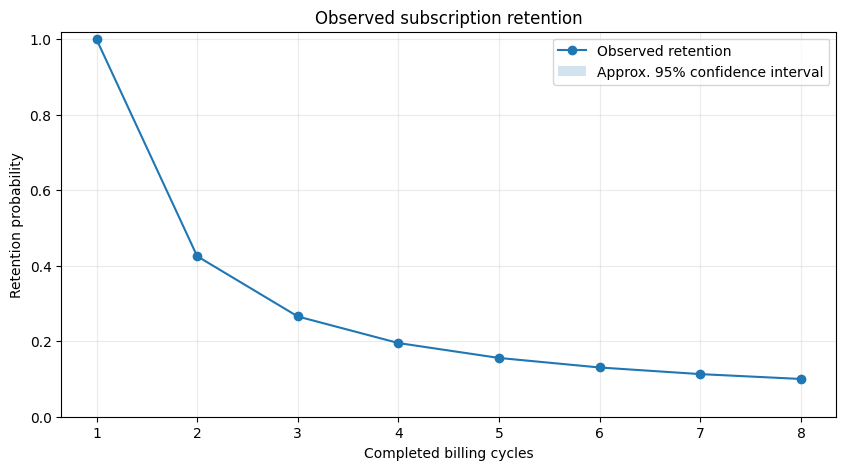

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(overall_retention["month"], overall_retention["retention"], marker="o", label="Observed retention")
ax.fill_between(
    overall_retention["month"],
    overall_retention["lower_ci"],
    overall_retention["upper_ci"],
    alpha=0.2,
    label="Approx. 95% confidence interval",
)
ax.set(title="Observed subscription retention", xlabel="Completed billing cycles", ylabel="Retention probability")
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.25)
ax.legend()
plt.show()

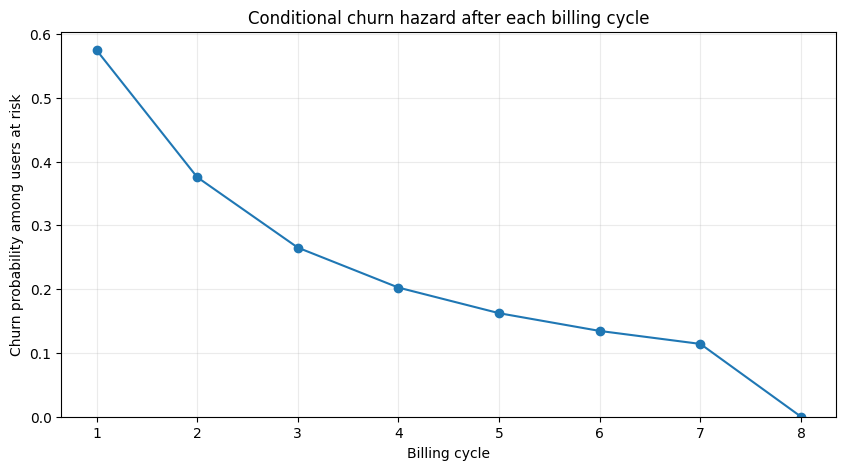

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly_hazard["cycle"], monthly_hazard["churn_hazard"], marker="o")
ax.set(title="Conditional churn hazard after each billing cycle", xlabel="Billing cycle", ylabel="Churn probability among users at risk")
ax.set_ylim(bottom=0)
ax.grid(alpha=0.25)
plt.show()

## 6. Retention by price, country, and acquisition source

In [17]:
def retention_by_segment(
    frame: pd.DataFrame,
    segment: str,
    max_cycle: int,
) -> pd.DataFrame:
    rows = []
    for value, group in frame.groupby(segment, dropna=False, observed=True):
        curve = kaplan_meier_curve(group, max_cycle)
        curve[segment] = value
        curve["subscribers"] = len(group)
        rows.append(curve)
    return pd.concat(rows, ignore_index=True)


def plot_segment_retention(
    curves: pd.DataFrame,
    segment: str,
    title: str,
) -> None:
    fig, ax = plt.subplots(figsize=(11, 6))
    for value, group in curves.groupby(segment, observed=True):
        ax.plot(group["month"], group["retention"], marker="o", label=str(value))
    ax.set(title=title, xlabel="Completed billing cycles", ylabel="Retention probability")
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.25)
    ax.legend(title=segment, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

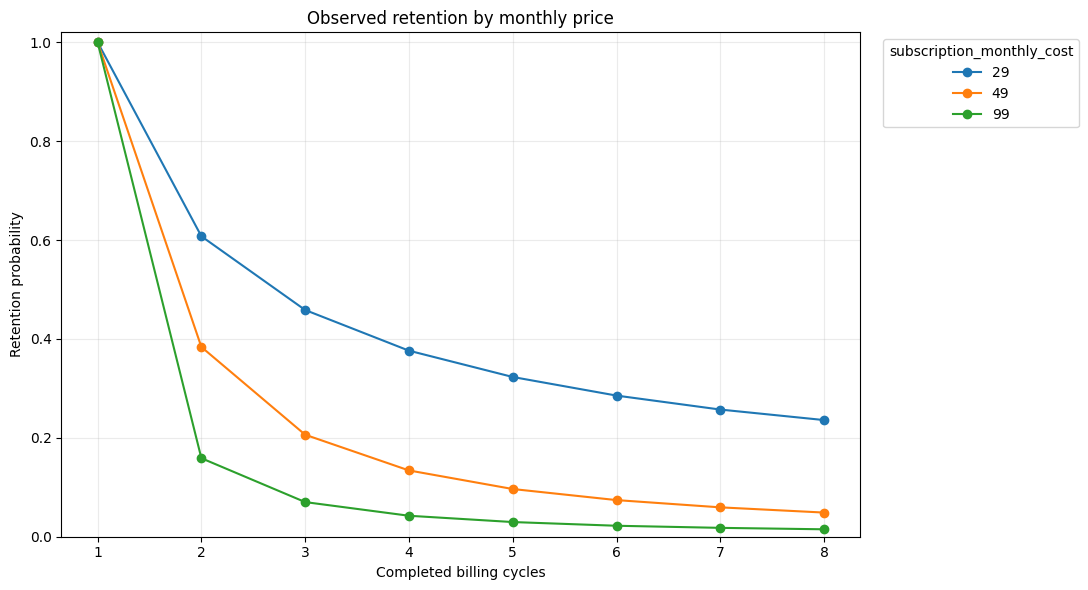

In [18]:
price_retention = retention_by_segment(df, "subscription_monthly_cost", OBSERVED_MAX_CYCLE)
plot_segment_retention(price_retention, "subscription_monthly_cost", "Observed retention by monthly price")

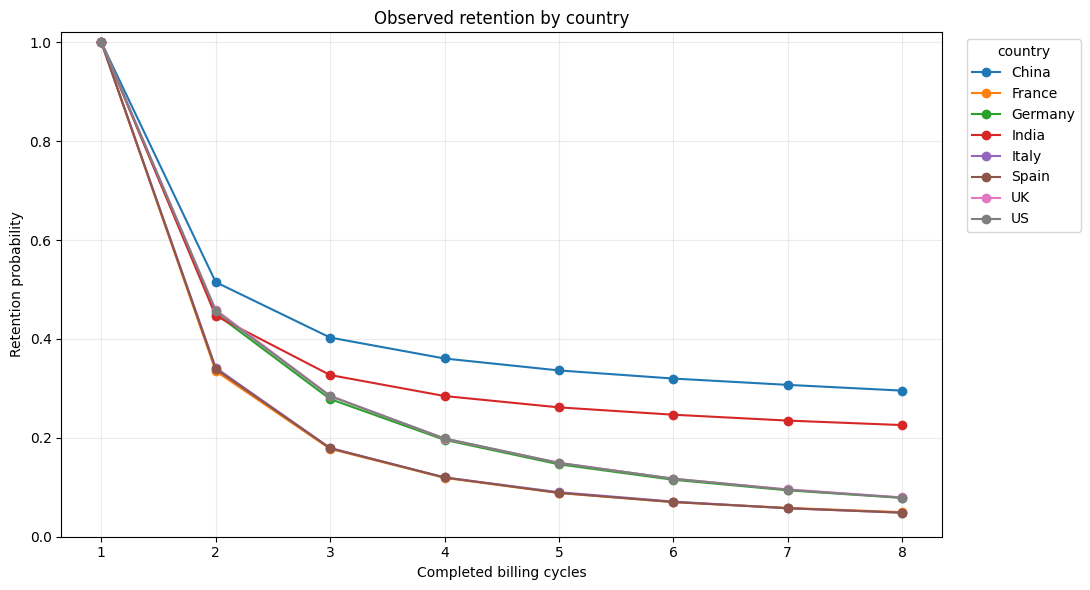

In [19]:
country_retention = retention_by_segment(df, "country", OBSERVED_MAX_CYCLE)
plot_segment_retention(country_retention, "country", "Observed retention by country")

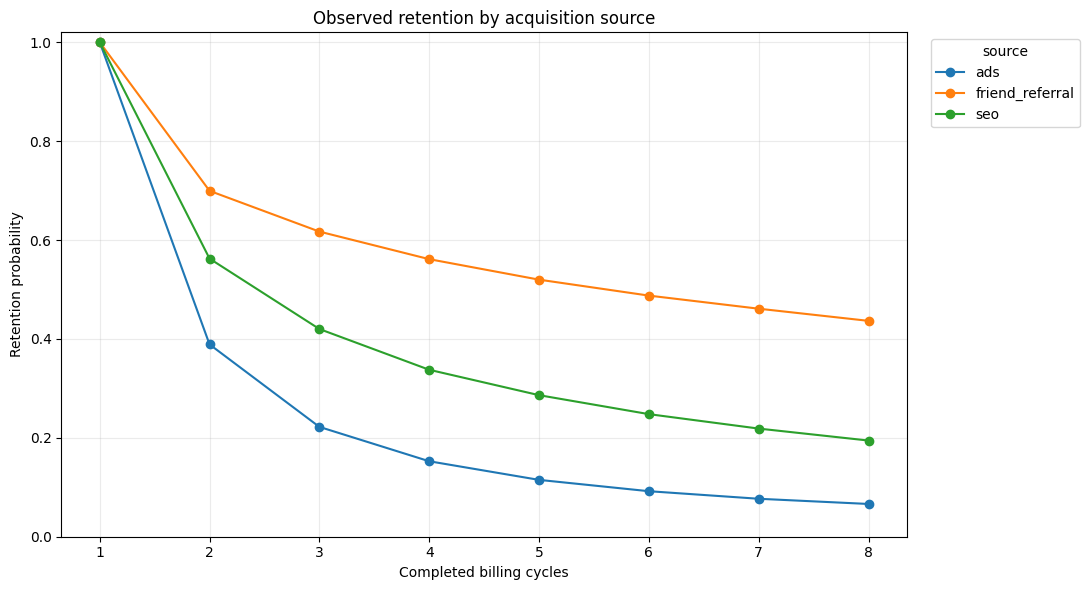

In [20]:
source_retention = retention_by_segment(df, "source", OBSERVED_MAX_CYCLE)
plot_segment_retention(source_retention, "source", "Observed retention by acquisition source")

In [21]:
def segment_summary(frame: pd.DataFrame, segment: str, horizons: list[int]) -> pd.DataFrame:
    records = []
    for value, group in frame.groupby(segment, dropna=False, observed=True):
        record = {
            segment: value,
            "subscribers": len(group),
            "subscriber_share": len(group) / len(frame),
            "mean_completed_cycles": group["billing_cycles"].mean(),
            "active_rate_at_observation_end": group["is_active"].mean(),
        }
        for month in horizons:
            record[f"retention_month_{month}"] = (group["billing_cycles"] >= month).mean()
        records.append(record)
    return pd.DataFrame(records).sort_values("subscribers", ascending=False)

KEY_HORIZONS = sorted(set([2, 4, 6, OBSERVED_MAX_CYCLE]))

print("Country summary")
display(segment_summary(df, "country", KEY_HORIZONS))
print("Source summary")
display(segment_summary(df, "source", KEY_HORIZONS))

Country summary


,country,subscribers,subscriber_share,mean_completed_cycles,active_rate_at_observation_end,retention_month_2,retention_month_4,retention_month_6,retention_month_8
7,US,91731,0.1835,2.3802,0.0790,0.4565,0.1989,0.1174,0.0790
6,UK,91252,0.1825,2.3841,0.0795,0.4589,0.1981,0.1174,0.0795
2,Germany,88944,0.1779,2.3596,0.0785,0.4513,0.1959,0.1152,0.0785
1,France,51662,0.1033,1.8981,0.0497,0.3349,0.1190,0.0699,0.0497
3,India,48027,0.0961,3.0272,0.2258,0.4467,0.2845,0.2467,0.2258
4,Italy,47459,0.0949,1.9085,0.0487,0.3417,0.1199,0.0711,0.0487
5,Spain,44987,0.0900,1.9028,0.0485,0.3391,0.1199,0.0701,0.0485
0,China,35938,0.0719,3.5367,0.2955,0.5148,0.3604,0.3199,0.2955


Source summary


,source,subscribers,subscriber_share,mean_completed_cycles,active_rate_at_observation_end,retention_month_2,retention_month_4,retention_month_6,retention_month_8
0,ads,414469,0.8289,2.1136,0.0662,0.3889,0.1526,0.0920,0.0662
2,seo,61103,0.1222,3.2673,0.1945,0.5624,0.3376,0.2479,0.1945
1,friend_referral,24428,0.0489,4.7828,0.4365,0.6994,0.5613,0.4876,0.4365


### Descriptive versus adjusted comparisons

The curves above are descriptive. They mix together price, country, and source composition.

For example, a country can have lower raw retention because it contains more high-price subscribers or a different source mix. The model below estimates **adjusted associations** by including price, country, source, and tenure in one equation.

These adjusted associations are still not causal. Pricing and acquisition source were not randomly assigned.

## 7. User-level train, validation, and test split

In [22]:
# Split users before constructing monthly risk sets, so the same subscriber can never
# appear in more than one dataset.
stratification_key = (
    df["is_active"].astype(str)
    + "_"
    + df["subscription_monthly_cost"].astype(str)
)

test_fraction_of_temp = TEST_SIZE / (VALIDATION_SIZE + TEST_SIZE)
train_df, temp_df = train_test_split(
    df,
    test_size=VALIDATION_SIZE + TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=stratification_key,
)

temp_stratification_key = (
    temp_df["is_active"].astype(str)
    + "_"
    + temp_df["subscription_monthly_cost"].astype(str)
)
valid_df, test_df = train_test_split(
    temp_df,
    test_size=test_fraction_of_temp,
    random_state=RANDOM_STATE,
    stratify=temp_stratification_key,
)

split_summary = pd.DataFrame({
    "train": [len(train_df), train_df["is_active"].mean(), train_df["billing_cycles"].mean()],
    "validation": [len(valid_df), valid_df["is_active"].mean(), valid_df["billing_cycles"].mean()],
    "test": [len(test_df), test_df["is_active"].mean(), test_df["billing_cycles"].mean()],
}, index=["users", "active_rate", "mean_billing_cycles"]).T
split_summary

,users,active_rate,mean_billing_cycles
train,"350,000.0000",0.1000,2.3851
validation,"75,000.0000",0.1000,2.3848
test,"75,000.0000",0.1000,2.3845


## 8. Build grouped discrete-time hazard data

A person-period survival dataset normally contains one row for every subscriber-cycle at risk. With 500,000 subscribers, that can exceed one million rows.

All users sharing the same cycle, price, country, and source have the same model features. We therefore aggregate them into binomial counts:

- `at_risk`: users who reached the cycle;
- `churned`: users who churned immediately after that cycle;
- `churn_rate = churned / at_risk`.

Using `freq_weights=at_risk` preserves the grouped binomial likelihood while making fitting much faster and more memory efficient.

In [23]:
def build_grouped_hazard_table(
    frame: pd.DataFrame,
    max_cycle: int,
) -> pd.DataFrame:
    rows = []
    group_columns = CATEGORICAL_COLUMNS

    for cycle in range(1, max_cycle + 1):
        at_risk = frame.loc[frame["billing_cycles"] >= cycle].copy()
        at_risk["churned_this_cycle"] = (
            (at_risk["churn_observed"] == 1)
            & (at_risk["billing_cycles"] == cycle)
        ).astype(int)

        grouped = (
            at_risk.groupby(group_columns, dropna=False, observed=True)["churned_this_cycle"]
            .agg(churned="sum", at_risk="size")
            .reset_index()
        )
        grouped["cycle"] = cycle
        grouped["churn_rate"] = grouped["churned"] / grouped["at_risk"]
        rows.append(grouped)

    return pd.concat(rows, ignore_index=True)


train_hazard = build_grouped_hazard_table(train_df, OBSERVED_MAX_CYCLE)
valid_hazard = build_grouped_hazard_table(valid_df, OBSERVED_MAX_CYCLE)
test_hazard = build_grouped_hazard_table(test_df, OBSERVED_MAX_CYCLE)

print(train_hazard.shape, valid_hazard.shape, test_hazard.shape)
train_hazard.head()

(567, 7) (545, 7) (543, 7)


,subscription_monthly_cost,country,source,churned,at_risk,cycle,churn_rate
0,29,China,ads,2124,9740,1,0.2181
1,29,China,friend_referral,69,557,1,0.1239
2,29,China,seo,267,1472,1,0.1814
3,29,France,ads,3917,8197,1,0.4779
4,29,France,friend_referral,135,520,1,0.2596


## 9. Complementary log-log hazard model

The model estimates the probability of churn after each cycle:


`h_{i,t}=P(T_i=t\mid T_i\ge t, X_i)`


using the complementary log-log link:

\[
\log[-\log(1-h_{i,t})] = \alpha(t) + \beta^T X_i
\]

This is a standard discrete-time proportional-hazards formulation.

- `alpha(t)` describes how baseline churn risk changes with tenure.
- price, country, and source enter as one-hot encoded linear effects.
- `exp(beta)` is interpreted as a multiplicative effect on the underlying hazard scale.
- the model automatically produces hazards between 0 and 1.
- multiplying monthly survival probabilities produces a monotonic retention curve.

In [24]:
def make_encoder(table: pd.DataFrame) -> OneHotEncoder:
    encoder = OneHotEncoder(
        handle_unknown="ignore",
        drop="first",
        sparse_output=False,
        dtype=float,
    )
    encoder.fit(table[CATEGORICAL_COLUMNS])
    return encoder


def build_design_matrix(
    table: pd.DataFrame,
    encoder: OneHotEncoder,
    time_specification: str,
    observed_max_cycle: int,
    include_covariates: bool = True,
) -> tuple[np.ndarray, list[str]]:
    cycle = table["cycle"].to_numpy(dtype=float)
    cycle_scaled = (cycle - 1) / max(observed_max_cycle - 1, 1)

    parts = [np.ones((len(table), 1))]
    names = ["const"]

    parts.append(cycle_scaled[:, None])
    names.append("cycle_scaled")

    if time_specification in {"log_linear", "log_quadratic", "price_time_interaction"}:
        parts.append(np.log(cycle)[:, None])
        names.append("log_cycle")

    if time_specification in {"log_quadratic", "price_time_interaction"}:
        parts.append((cycle_scaled ** 2)[:, None])
        names.append("cycle_scaled_sq")

    if include_covariates:
        category_matrix = encoder.transform(table[CATEGORICAL_COLUMNS])
        category_names = list(encoder.get_feature_names_out(CATEGORICAL_COLUMNS))
        parts.append(category_matrix)
        names.extend(category_names)

        if time_specification == "price_time_interaction":
            for index, name in enumerate(category_names):
                if name.startswith("subscription_monthly_cost_"):
                    parts.append((category_matrix[:, index] * cycle_scaled)[:, None])
                    names.append(f"{name}:cycle_scaled")

    return np.column_stack(parts), names


def fit_hazard_model(
    hazard_table: pd.DataFrame,
    encoder: OneHotEncoder,
    time_specification: str,
    include_covariates: bool = True,
):
    design, names = build_design_matrix(
        hazard_table,
        encoder,
        time_specification,
        OBSERVED_MAX_CYCLE,
        include_covariates=include_covariates,
    )
    model = sm.GLM(
        hazard_table["churn_rate"].to_numpy(),
        design,
        family=sm.families.Binomial(link=sm.families.links.CLogLog()),
        freq_weights=hazard_table["at_risk"].to_numpy(),
    ).fit(maxiter=200)
    return model, names

## 10. Validation-based time-shape selection

Only eight cycles are observed, so the future shape cannot be learned without assumptions. The notebook compares several parsimonious tenure functions:

- linear tenure;
- linear plus log tenure;
- linear, log, and quadratic tenure;
- the same flexible shape plus price-by-tenure interactions.

Selection uses validation probability loss and retention Brier scores. The test set is not used for this choice.

In [25]:
def grouped_log_loss(hazard_table: pd.DataFrame, probability: np.ndarray) -> float:
    probability = np.clip(np.asarray(probability), 1e-10, 1 - 1e-10)
    events = hazard_table["churned"].to_numpy(dtype=float)
    total = hazard_table["at_risk"].to_numpy(dtype=float)
    negative_log_likelihood = -(
        events * np.log(probability)
        + (total - events) * np.log(1 - probability)
    ).sum()
    return float(negative_log_likelihood / total.sum())


def profile_survival_table(
    model,
    encoder: OneHotEncoder,
    time_specification: str,
    profiles: pd.DataFrame,
    horizon: int,
    include_covariates: bool = True,
) -> pd.DataFrame:
    profile_columns = CATEGORICAL_COLUMNS
    unique_profiles = profiles[profile_columns].drop_duplicates().copy()
    cycle_grid = pd.DataFrame({"cycle": np.arange(1, horizon)})
    grid = unique_profiles.merge(cycle_grid, how="cross")

    design, _ = build_design_matrix(
        grid,
        encoder,
        time_specification,
        OBSERVED_MAX_CYCLE,
        include_covariates=include_covariates,
    )
    grid["hazard"] = np.clip(model.predict(design), 1e-10, 1 - 1e-10)
    grid = grid.sort_values(profile_columns + ["cycle"])
    grid["survival_after_cycle"] = (
        grid.groupby(profile_columns, observed=True)["hazard"]
        .transform(lambda series: (1 - series).cumprod())
    )

    rows = []
    for profile_values, group in grid.groupby(profile_columns, observed=True, sort=False):
        if not isinstance(profile_values, tuple):
            profile_values = (profile_values,)
        profile = dict(zip(profile_columns, profile_values))
        rows.append({**profile, "month": 1, "predicted_retention": 1.0})
        for month in range(2, horizon + 1):
            value = group.loc[
                group["cycle"] == month - 1,
                "survival_after_cycle",
            ].iloc[0]
            rows.append({**profile, "month": month, "predicted_retention": float(value)})

    return pd.DataFrame(rows)


def score_users_at_horizons(
    model,
    encoder: OneHotEncoder,
    time_specification: str,
    users: pd.DataFrame,
    horizons: list[int],
    include_covariates: bool = True,
) -> pd.DataFrame:
    max_horizon = max(horizons)
    survival = profile_survival_table(
        model,
        encoder,
        time_specification,
        users,
        horizon=max_horizon,
        include_covariates=include_covariates,
    )
    wide = survival.pivot(
        index=CATEGORICAL_COLUMNS,
        columns="month",
        values="predicted_retention",
    ).reset_index()
    wide = wide.rename(columns={
        month: f"pred_retention_m{month}"
        for month in range(1, max_horizon + 1)
    })
    return users.merge(wide, on=CATEGORICAL_COLUMNS, how="left", validate="many_to_one")


def horizon_brier_scores(scored_users: pd.DataFrame, horizons: list[int]) -> dict[str, float]:
    scores = {}
    for month in horizons:
        actual = (scored_users["billing_cycles"] >= month).astype(int)
        predicted = scored_users[f"pred_retention_m{month}"]
        scores[f"brier_m{month}"] = brier_score_loss(actual, predicted)
    return scores

In [26]:
EVALUATION_HORIZONS = sorted(set(
    month for month in [2, 4, 6, OBSERVED_MAX_CYCLE]
    if month <= OBSERVED_MAX_CYCLE
))
TIME_SPECIFICATIONS = [
    "linear",
    "log_linear",
    "log_quadratic",
    "price_time_interaction",
]

train_encoder = make_encoder(train_hazard)
validation_records = []
validation_models = {}

for specification in TIME_SPECIFICATIONS:
    candidate_model, candidate_names = fit_hazard_model(
        train_hazard,
        train_encoder,
        specification,
        include_covariates=True,
    )
    validation_design, _ = build_design_matrix(
        valid_hazard,
        train_encoder,
        specification,
        OBSERVED_MAX_CYCLE,
        include_covariates=True,
    )
    validation_hazard_probability = candidate_model.predict(validation_design)
    scored_validation = score_users_at_horizons(
        candidate_model,
        train_encoder,
        specification,
        valid_df,
        EVALUATION_HORIZONS,
        include_covariates=True,
    )
    brier_scores = horizon_brier_scores(scored_validation, EVALUATION_HORIZONS)

    validation_records.append({
        "time_specification": specification,
        "parameters": len(candidate_names),
        "train_aic": candidate_model.aic,
        "validation_grouped_log_loss": grouped_log_loss(
            valid_hazard,
            validation_hazard_probability,
        ),
        "validation_mean_brier": np.mean(list(brier_scores.values())),
        **brier_scores,
    })
    validation_models[specification] = candidate_model

validation_results = (
    pd.DataFrame(validation_records)
    .sort_values(["validation_mean_brier", "validation_grouped_log_loss"])
    .reset_index(drop=True)
)
validation_results

,time_specification,parameters,train_aic,validation_grouped_log_loss,validation_mean_brier,brier_m2,brier_m4,brier_m6,brier_m8
0,log_linear,14,"605,142.1471",0.5295,0.1266,0.2176,0.1279,0.0899,0.0710
1,log_quadratic,15,"603,765.2688",0.5286,0.1266,0.2176,0.1279,0.0899,0.0710
2,linear,13,"605,542.9300",0.5297,0.1266,0.2176,0.1280,0.0900,0.0711
3,price_time_interaction,17,"602,725.4664",0.5281,0.1267,0.2172,0.1281,0.0901,0.0712


In [27]:
SELECTED_TIME_SPECIFICATION = validation_results.loc[0, "time_specification"]
print(f"Selected time specification: {SELECTED_TIME_SPECIFICATION}")
print(
    "Selection was based only on the validation set. "
    "The final model will now be refit on training + validation users."
)

Selected time specification: log_linear
Selection was based only on the validation set. The final model will now be refit on training + validation users.


## 11. Fit the final contextual model and a time-only baseline

In [28]:
train_valid_df = pd.concat([train_df, valid_df], ignore_index=True)
train_valid_hazard = build_grouped_hazard_table(train_valid_df, OBSERVED_MAX_CYCLE)
final_encoder = make_encoder(train_valid_hazard)

final_model, final_feature_names = fit_hazard_model(
    train_valid_hazard,
    final_encoder,
    SELECTED_TIME_SPECIFICATION,
    include_covariates=True,
)

baseline_model, baseline_feature_names = fit_hazard_model(
    train_valid_hazard,
    final_encoder,
    SELECTED_TIME_SPECIFICATION,
    include_covariates=False,
)

print(f"Contextual model parameters: {len(final_feature_names)}")
print(f"Time-only baseline parameters: {len(baseline_feature_names)}")

Contextual model parameters: 14
Time-only baseline parameters: 3


## 12. Final test evaluation

In [29]:
# Hazard-level probability loss.
test_context_design, _ = build_design_matrix(
    test_hazard,
    final_encoder,
    SELECTED_TIME_SPECIFICATION,
    OBSERVED_MAX_CYCLE,
    include_covariates=True,
)
test_baseline_design, _ = build_design_matrix(
    test_hazard,
    final_encoder,
    SELECTED_TIME_SPECIFICATION,
    OBSERVED_MAX_CYCLE,
    include_covariates=False,
)

context_hazard_probability = final_model.predict(test_context_design)
baseline_hazard_probability = baseline_model.predict(test_baseline_design)

scored_test = score_users_at_horizons(
    final_model,
    final_encoder,
    SELECTED_TIME_SPECIFICATION,
    test_df,
    EVALUATION_HORIZONS,
    include_covariates=True,
)
scored_test_baseline = score_users_at_horizons(
    baseline_model,
    final_encoder,
    SELECTED_TIME_SPECIFICATION,
    test_df,
    EVALUATION_HORIZONS,
    include_covariates=False,
)

context_brier = horizon_brier_scores(scored_test, EVALUATION_HORIZONS)
baseline_brier = horizon_brier_scores(scored_test_baseline, EVALUATION_HORIZONS)

test_metrics = pd.DataFrame([
    {
        "model": "Time-only baseline",
        "grouped_log_loss": grouped_log_loss(test_hazard, baseline_hazard_probability),
        "mean_horizon_brier": np.mean(list(baseline_brier.values())),
        **baseline_brier,
    },
    {
        "model": "Contextual discrete-time survival model",
        "grouped_log_loss": grouped_log_loss(test_hazard, context_hazard_probability),
        "mean_horizon_brier": np.mean(list(context_brier.values())),
        **context_brier,
    },
]).set_index("model")

test_metrics

,grouped_log_loss,mean_horizon_brier,brier_m2,brier_m4,brier_m6,brier_m8
model,,,,,,
Time-only baseline,0.5799,0.1513,0.2443,0.1570,0.1137,0.0900
Contextual discrete-time survival model,0.5294,0.1270,0.2175,0.1291,0.0905,0.0708


In [30]:
# Compare the average predicted retention curve with the observed test retention curve.
all_test_months = list(range(1, OBSERVED_MAX_CYCLE + 1))
scored_test_all_months = score_users_at_horizons(
    final_model,
    final_encoder,
    SELECTED_TIME_SPECIFICATION,
    test_df,
    all_test_months,
    include_covariates=True,
)
scored_test_baseline_all_months = score_users_at_horizons(
    baseline_model,
    final_encoder,
    SELECTED_TIME_SPECIFICATION,
    test_df,
    all_test_months,
    include_covariates=False,
)

test_curve = pd.DataFrame({
    "month": all_test_months,
    "observed_retention": [
        (test_df["billing_cycles"] >= month).mean()
        for month in all_test_months
    ],
    "contextual_prediction": [
        scored_test_all_months[f"pred_retention_m{month}"].mean()
        for month in all_test_months
    ],
    "baseline_prediction": [
        scored_test_baseline_all_months[f"pred_retention_m{month}"].mean()
        for month in all_test_months
    ],
})
test_curve["contextual_absolute_error"] = (
    test_curve["observed_retention"] - test_curve["contextual_prediction"]
).abs()
test_curve

,month,observed_retention,contextual_prediction,baseline_prediction,contextual_absolute_error
0,1,1.0000,1.0000,1.0000,0.0000
1,2,0.4246,0.4308,0.4274,0.0062
2,3,0.2649,0.2664,0.2627,0.0015
3,4,0.1950,0.1942,0.1910,0.0008
4,5,0.1566,0.1556,0.1531,0.0010
5,6,0.1308,0.1323,0.1307,0.0016
6,7,0.1126,0.1173,0.1165,0.0047
7,8,0.1000,0.1069,0.1070,0.0069


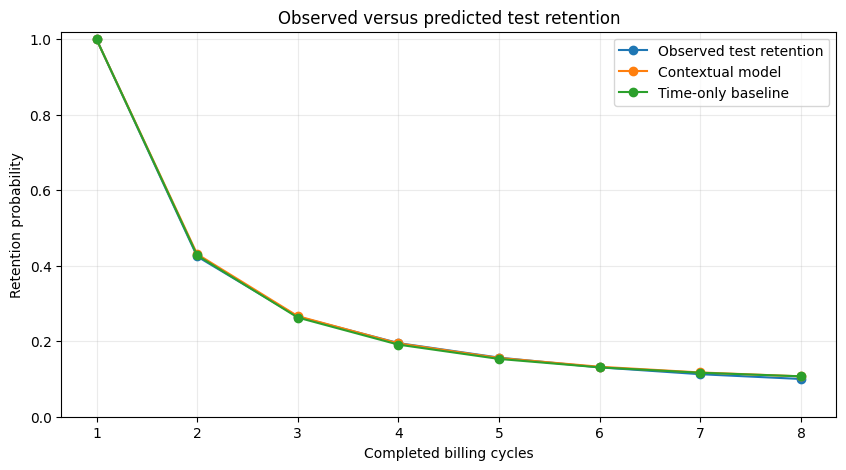

In [31]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(test_curve["month"], test_curve["observed_retention"], marker="o", label="Observed test retention")
ax.plot(test_curve["month"], test_curve["contextual_prediction"], marker="o", label="Contextual model")
ax.plot(test_curve["month"], test_curve["baseline_prediction"], marker="o", label="Time-only baseline")
ax.set(title="Observed versus predicted test retention", xlabel="Completed billing cycles", ylabel="Retention probability")
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.25)
ax.legend()
plt.show()

## 13. Retention calibration at the last observed horizon

In [32]:
calibration_month = OBSERVED_MAX_CYCLE
calibration_data = scored_test_all_months.copy()
calibration_data["predicted_retention"] = calibration_data[
    f"pred_retention_m{calibration_month}"
]
calibration_data["observed_retained"] = (
    calibration_data["billing_cycles"] >= calibration_month
).astype(int)
calibration_data["risk_group"] = pd.qcut(
    calibration_data["predicted_retention"],
    q=10,
    duplicates="drop",
)

calibration_table = (
    calibration_data.groupby("risk_group", observed=True)
    .agg(
        users=("user_id", "size"),
        mean_predicted_retention=("predicted_retention", "mean"),
        observed_retention=("observed_retained", "mean"),
    )
    .reset_index()
)
calibration_table

,risk_group,users,mean_predicted_retention,observed_retention
0,"(-0.000905, 0.00624]",10204,0.0033,0.0026
1,"(0.00624, 0.00643]",7330,0.0064,0.0008
2,"(0.00643, 0.0338]",7307,0.0323,0.0297
3,"(0.0338, 0.0343]",6824,0.0343,0.0331
4,"(0.0343, 0.0358]",6821,0.0358,0.0298
5,"(0.0358, 0.0679]",8156,0.0545,0.0139
6,"(0.0679, 0.161]",6071,0.1060,0.0982
7,"(0.161, 0.209]",9112,0.1971,0.0951
8,"(0.209, 0.271]",5816,0.2280,0.2782
9,"(0.271, 0.724]",7359,0.4097,0.4929


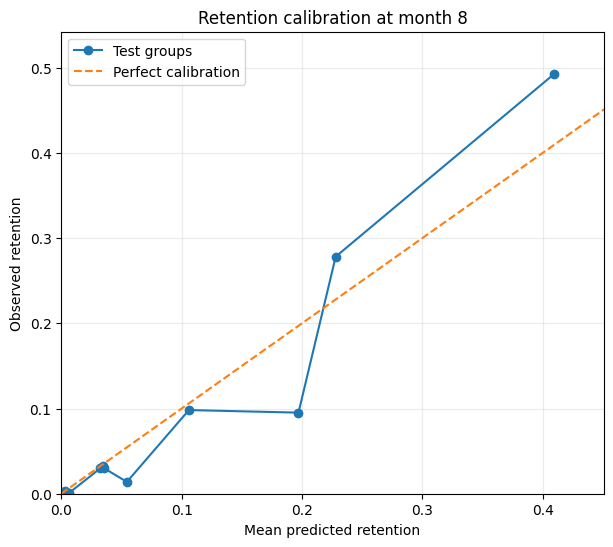

In [33]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(
    calibration_table["mean_predicted_retention"],
    calibration_table["observed_retention"],
    marker="o",
    label="Test groups",
)
ax.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
ax.set(
    title=f"Retention calibration at month {calibration_month}",
    xlabel="Mean predicted retention",
    ylabel="Observed retention",
)
ax.set_xlim(0, max(0.05, calibration_table["mean_predicted_retention"].max() * 1.1))
ax.set_ylim(0, max(0.05, calibration_table["observed_retention"].max() * 1.1))
ax.grid(alpha=0.25)
ax.legend()
plt.show()

## 14. Adjusted price, country, and source associations

For the complementary log-log model, exponentiated coefficients are multiplicative effects on the modeled hazard scale.

- value above 1: higher adjusted churn hazard and lower retention;
- value below 1: lower adjusted churn hazard and higher retention;
- value near 1: little adjusted difference from the reference group.

The first category learned by the encoder is the reference category and is not shown as a coefficient.

In [34]:
confidence_interval = np.asarray(final_model.conf_int())
coefficient_table = pd.DataFrame({
    "feature": final_feature_names,
    "coefficient": np.asarray(final_model.params),
    "standard_error": np.asarray(final_model.bse),
    "lower_coefficient": confidence_interval[:, 0],
    "upper_coefficient": confidence_interval[:, 1],
})
coefficient_table["hazard_multiplier"] = np.exp(coefficient_table["coefficient"])
coefficient_table["lower_hazard_multiplier"] = np.exp(coefficient_table["lower_coefficient"])
coefficient_table["upper_hazard_multiplier"] = np.exp(coefficient_table["upper_coefficient"])

reference_levels = {
    column: list(categories)[0]
    for column, categories in zip(CATEGORICAL_COLUMNS, final_encoder.categories_)
}
print("Reference levels:", reference_levels)

adjusted_effects = coefficient_table.loc[
    coefficient_table["feature"].str.startswith((
        "subscription_monthly_cost_",
        "country_",
        "source_",
    ))
].sort_values("hazard_multiplier", ascending=False)
adjusted_effects

Reference levels: {'subscription_monthly_cost': np.int64(29), 'country': 'China', 'source': 'ads'}


,feature,coefficient,standard_error,lower_coefficient,upper_coefficient,hazard_multiplier,lower_hazard_multiplier,upper_hazard_multiplier
4,subscription_monthly_cost_99,1.3675,0.0066,1.3546,1.3805,3.9256,3.8751,3.9768
3,subscription_monthly_cost_49,0.7662,0.0041,0.7582,0.7741,2.1515,2.1344,2.1687
8,country_Italy,0.6349,0.0087,0.6178,0.6520,1.8868,1.8548,1.9195
5,country_France,0.6300,0.0086,0.6131,0.6469,1.8776,1.8462,1.9096
9,country_Spain,0.6292,0.0088,0.6119,0.6466,1.8762,1.8440,1.9090
11,country_US,0.2308,0.0079,0.2154,0.2463,1.2596,1.2403,1.2792
10,country_UK,0.2257,0.0079,0.2103,0.2412,1.2532,1.2340,1.2728
6,country_Germany,0.2134,0.0079,0.1979,0.2290,1.2379,1.2188,1.2573
7,country_India,0.1501,0.0088,0.1330,0.1673,1.1620,1.1422,1.1821
13,source_seo,-0.6190,0.0053,-0.6294,-0.6086,0.5385,0.5329,0.5441


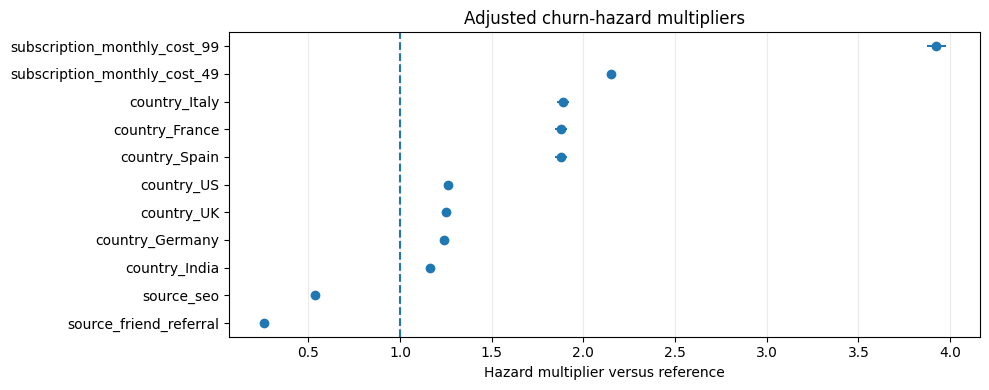

In [35]:
plot_effects = adjusted_effects.loc[
    ~adjusted_effects["feature"].str.contains(":cycle_scaled")
].copy()
plot_effects = plot_effects.sort_values("hazard_multiplier")

fig, ax = plt.subplots(figsize=(10, max(4, len(plot_effects) * 0.35)))
ax.errorbar(
    plot_effects["hazard_multiplier"],
    np.arange(len(plot_effects)),
    xerr=[
        plot_effects["hazard_multiplier"] - plot_effects["lower_hazard_multiplier"],
        plot_effects["upper_hazard_multiplier"] - plot_effects["hazard_multiplier"],
    ],
    fmt="o",
)
ax.axvline(1.0, linestyle="--")
ax.set_yticks(np.arange(len(plot_effects)))
ax.set_yticklabels(plot_effects["feature"])
ax.set(title="Adjusted churn-hazard multipliers", xlabel="Hazard multiplier versus reference", ylabel="")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

### Interpretation caution

These coefficients control for the observed price, country, source, and modeled tenure shape. They do **not** prove that changing a user's country, source, or price would cause the predicted effect.

Potential confounders include product mix, purchasing power, acquisition intent, promotion history, payment method, service quality, and competitor presence.

## 15. Standardized retention forecast by price through month 12

To compare price points more fairly, the notebook applies each price to the **same observed country/source distribution**. This removes differences caused only by one price group having a different market mix.

This is adjusted prediction, not a randomized price experiment. Months beyond the observed maximum are model-based extrapolations.

In [36]:
def standardized_price_profiles(frame: pd.DataFrame) -> pd.DataFrame:
    market_mix = (
        frame.groupby(["country", "source"], observed=True)
        .size()
        .rename("weight")
        .reset_index()
    )
    prices = pd.DataFrame({
        "subscription_monthly_cost": sorted(frame["subscription_monthly_cost"].unique())
    })
    return prices.merge(market_mix, how="cross")


standard_profiles = standardized_price_profiles(train_valid_df)
standard_survival = profile_survival_table(
    final_model,
    final_encoder,
    SELECTED_TIME_SPECIFICATION,
    standard_profiles,
    horizon=FORECAST_HORIZON,
    include_covariates=True,
).merge(
    standard_profiles,
    on=CATEGORICAL_COLUMNS,
    how="left",
    validate="many_to_one",
)

standardized_price_forecast = (
    standard_survival.assign(
        weighted_retention=lambda x: x["predicted_retention"] * x["weight"]
    )
    .groupby(["subscription_monthly_cost", "month"], observed=True)
    .agg(
        weighted_retention=("weighted_retention", "sum"),
        total_weight=("weight", "sum"),
    )
    .assign(predicted_retention=lambda x: x["weighted_retention"] / x["total_weight"])
    .reset_index()
)
standardized_price_forecast.head(15)

,subscription_monthly_cost,month,weighted_retention,total_weight,predicted_retention
0,29,1,"425,000.0000",425000,1.0000
1,29,2,"266,959.9749",425000,0.6281
2,29,3,"195,847.1013",425000,0.4608
3,29,4,"156,774.8448",425000,0.3689
4,29,5,"132,882.2316",425000,0.3127
5,29,6,"117,227.9067",425000,0.2758
6,29,7,"106,465.1904",425000,0.2505
7,29,8,"98,801.2247",425000,0.2325
8,29,9,"93,198.4075",425000,0.2193
9,29,10,"89,019.3070",425000,0.2095


### Model-based uncertainty simulation

In [37]:
def nearest_positive_semidefinite(matrix: np.ndarray) -> np.ndarray:
    symmetric = (matrix + matrix.T) / 2
    eigenvalues, eigenvectors = np.linalg.eigh(symmetric)
    eigenvalues = np.clip(eigenvalues, 1e-12, None)
    return eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T


def simulate_standardized_price_forecast(
    model,
    encoder: OneHotEncoder,
    time_specification: str,
    profiles: pd.DataFrame,
    horizon: int,
    simulations: int,
    seed: int,
) -> pd.DataFrame:
    profile_columns = CATEGORICAL_COLUMNS
    unique_profiles = profiles[profile_columns + ["weight"]].copy()
    grid = unique_profiles.merge(
        pd.DataFrame({"cycle": np.arange(1, horizon)}),
        how="cross",
    ).sort_values(profile_columns + ["cycle"]).reset_index(drop=True)

    design, _ = build_design_matrix(
        grid,
        encoder,
        time_specification,
        OBSERVED_MAX_CYCLE,
        include_covariates=True,
    )
    covariance = nearest_positive_semidefinite(np.asarray(model.cov_params()))
    simulation_rng = np.random.default_rng(seed)
    parameter_draws = simulation_rng.multivariate_normal(
        np.asarray(model.params),
        covariance,
        size=simulations,
        check_valid="ignore",
    )

    linear_predictor = design @ parameter_draws.T
    hazard_draws = 1 - np.exp(-np.exp(linear_predictor))
    hazard_draws = np.clip(hazard_draws, 1e-10, 1 - 1e-10)

    profile_keys = list(grid.groupby(profile_columns, observed=True, sort=False).groups.keys())
    profile_survival_draws = []
    profile_metadata = []

    for key in profile_keys:
        if not isinstance(key, tuple):
            key = (key,)
        mask = np.ones(len(grid), dtype=bool)
        for column, value in zip(profile_columns, key):
            mask &= grid[column].to_numpy() == value
        cycle_hazards = hazard_draws[mask]
        survival = np.vstack([
            np.ones((1, simulations)),
            np.cumprod(1 - cycle_hazards, axis=0),
        ])
        profile_survival_draws.append(survival)
        metadata_row = grid.loc[mask].iloc[0]
        profile_metadata.append({
            **dict(zip(profile_columns, key)),
            "weight": float(metadata_row["weight"]),
        })

    profile_metadata = pd.DataFrame(profile_metadata)
    profile_survival_draws = np.stack(profile_survival_draws, axis=0)

    output = []
    for price in sorted(profile_metadata["subscription_monthly_cost"].unique()):
        price_mask = profile_metadata["subscription_monthly_cost"].to_numpy() == price
        weights = profile_metadata.loc[price_mask, "weight"].to_numpy(dtype=float)
        weights = weights / weights.sum()
        aggregated = np.tensordot(
            weights,
            profile_survival_draws[price_mask],
            axes=(0, 0),
        )
        for month in range(1, horizon + 1):
            draws = aggregated[month - 1]
            output.append({
                "subscription_monthly_cost": price,
                "month": month,
                "lower_95": float(np.quantile(draws, 0.025)),
                "median_simulation": float(np.quantile(draws, 0.50)),
                "upper_95": float(np.quantile(draws, 0.975)),
            })

    return pd.DataFrame(output)


forecast_intervals = simulate_standardized_price_forecast(
    final_model,
    final_encoder,
    SELECTED_TIME_SPECIFICATION,
    standard_profiles,
    FORECAST_HORIZON,
    N_PARAMETER_SIMULATIONS,
    RANDOM_STATE,
)

standardized_price_forecast = standardized_price_forecast.merge(
    forecast_intervals,
    on=["subscription_monthly_cost", "month"],
    how="left",
    validate="one_to_one",
)
standardized_price_forecast.tail(12)

,subscription_monthly_cost,month,weighted_retention,total_weight,predicted_retention,lower_95,median_simulation,upper_95
24,99,1,"425,000.0000",425000,1.0000,1.0000,1.0000,1.0000
25,99,2,"78,798.5804",425000,0.1854,0.1823,0.1854,0.1883
26,99,3,"30,471.5449",425000,0.0717,0.0700,0.0717,0.0733
27,99,4,"16,859.7542",425000,0.0397,0.0386,0.0397,0.0407
28,99,5,"11,375.0638",425000,0.0268,0.0260,0.0268,0.0276
29,99,6,"8,640.5093",425000,0.0203,0.0197,0.0203,0.0210
30,99,7,"7,079.1180",425000,0.0167,0.0162,0.0166,0.0172
31,99,8,"6,103.1758",425000,0.0144,0.0139,0.0143,0.0149
32,99,9,"5,453.7068",425000,0.0128,0.0124,0.0128,0.0133
33,99,10,"5,001.6878",425000,0.0118,0.0114,0.0118,0.0122


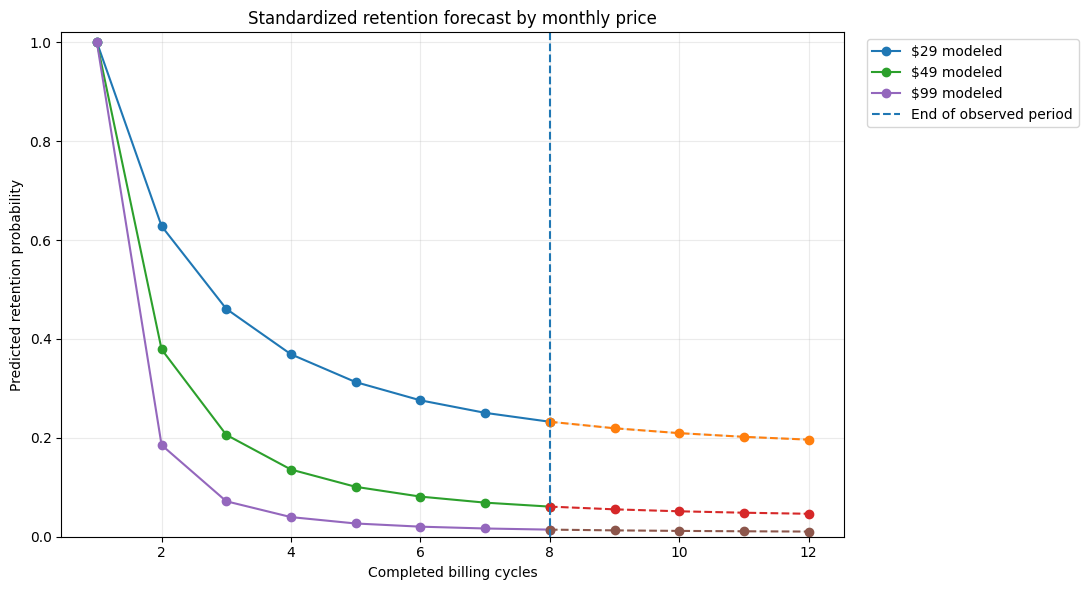

In [38]:
fig, ax = plt.subplots(figsize=(11, 6))
for price, group in standardized_price_forecast.groupby("subscription_monthly_cost", observed=True):
    observed = group[group["month"] <= OBSERVED_MAX_CYCLE]
    extrapolated = group[group["month"] >= OBSERVED_MAX_CYCLE]
    ax.plot(observed["month"], observed["predicted_retention"], marker="o", label=f"${price} modeled")
    ax.plot(extrapolated["month"], extrapolated["predicted_retention"], marker="o", linestyle="--")
    ax.fill_between(extrapolated["month"], extrapolated["lower_95"], extrapolated["upper_95"], alpha=0.12)

ax.axvline(OBSERVED_MAX_CYCLE, linestyle="--", label="End of observed period")
ax.set(
    title="Standardized retention forecast by monthly price",
    xlabel="Completed billing cycles",
    ylabel="Predicted retention probability",
)
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.25)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [39]:
month_12_forecast = (
    standardized_price_forecast.loc[
        standardized_price_forecast["month"] == FORECAST_HORIZON,
        [
            "subscription_monthly_cost",
            "predicted_retention",
            "lower_95",
            "upper_95",
        ],
    ]
    .sort_values("subscription_monthly_cost")
    .reset_index(drop=True)
)
month_12_forecast

,subscription_monthly_cost,predicted_retention,lower_95,upper_95
0,29,0.1963,0.1944,0.1984
1,49,0.0464,0.0457,0.0472
2,99,0.0104,0.0101,0.0108


The uncertainty interval above reflects coefficient uncertainty under the fitted model. It does **not** fully represent uncertainty from choosing a time-shape assumption or extrapolating beyond the observed period. The latter can be much larger.

## 16. Expected 12-month revenue per acquired subscriber

If payment occurs at the beginning of each retained monthly cycle, an approximate expected 12-month subscription revenue is:

\[
\text{Expected revenue} = \text{monthly price}\times\sum_{m=1}^{12}S(m)
\]

This calculation excludes acquisition cost, discounts, payment failures, taxes, refunds, upgrades, downgrades, reactivation, and gross margin.

In [40]:
price_revenue_forecast = (
    standardized_price_forecast.groupby("subscription_monthly_cost", observed=True)
    .agg(
        expected_paid_cycles_12m=("predicted_retention", "sum"),
        month_12_retention=("predicted_retention", "last"),
    )
    .reset_index()
)
price_revenue_forecast["expected_subscription_revenue_12m"] = (
    price_revenue_forecast["subscription_monthly_cost"]
    * price_revenue_forecast["expected_paid_cycles_12m"]
)
price_revenue_forecast

,subscription_monthly_cost,expected_paid_cycles_12m,month_12_retention,expected_subscription_revenue_12m
0,29,4.3564,0.1963,126.3346
1,49,2.2344,0.0464,109.4853
2,99,1.4209,0.0104,140.6724


### Revenue interpretation

A higher price can have lower retention and still generate more expected revenue. The correct decision depends on:

- acquisition cost by channel;
- gross margin and service cost;
- upgrade and downgrade behavior;
- customer lifetime value beyond 12 months;
- willingness-to-pay and conversion effects at signup;
- causal results from randomized or quasi-experimental price tests.

This notebook only models retention among people who already subscribed. It does not model how price changes signup conversion.

## 17. Opportunity tables for country and source

In [41]:
def opportunity_table(
    frame: pd.DataFrame,
    segment: str,
    month: int,
) -> pd.DataFrame:
    overall_retention_at_month = (frame["billing_cycles"] >= month).mean()
    table = (
        frame.groupby(segment, observed=True)
        .agg(
            subscribers=("user_id", "size"),
            retained=("billing_cycles", lambda series: int((series >= month).sum())),
            average_price=("subscription_monthly_cost", "mean"),
        )
        .assign(
            retention=lambda x: x["retained"] / x["subscribers"],
            subscriber_share=lambda x: x["subscribers"] / x["subscribers"].sum(),
            retention_lift_vs_overall=lambda x: x["retention"] / overall_retention_at_month,
            expected_retained_at_overall=lambda x: x["subscribers"] * overall_retention_at_month,
            retained_gap_vs_overall=lambda x: x["retained"] - x["expected_retained_at_overall"],
        )
        .sort_values("retained_gap_vs_overall")
    )
    return table


print(f"Country opportunities at month {OBSERVED_MAX_CYCLE}")
display(opportunity_table(df, "country", OBSERVED_MAX_CYCLE))
print(f"Source opportunities at month {OBSERVED_MAX_CYCLE}")
display(opportunity_table(df, "source", OBSERVED_MAX_CYCLE))

Country opportunities at month 8


,subscribers,retained,average_price,retention,subscriber_share,retention_lift_vs_overall,expected_retained_at_overall,retained_gap_vs_overall
country,,,,,,,,
France,51662,2567,49.6188,0.0497,0.1033,0.4969,"5,166.0967","-2,599.0967"
Italy,47459,2311,48.1683,0.0487,0.0949,0.4870,"4,745.8051","-2,434.8051"
Spain,44987,2182,48.4032,0.0485,0.0900,0.4850,"4,498.6100","-2,316.6100"
US,91731,7245,49.4162,0.0790,0.1835,0.7898,"9,172.9165","-1,927.9165"
Germany,88944,6979,50.6485,0.0785,0.1779,0.7847,"8,894.2221","-1,915.2221"
UK,91252,7254,49.5658,0.0795,0.1825,0.7950,"9,125.0175","-1,871.0175"
India,48027,10843,45.5592,0.2258,0.0961,2.2577,"4,802.6039","6,040.3961"
China,35938,10618,40.5961,0.2955,0.0719,2.9546,"3,593.7281","7,024.2719"


Source opportunities at month 8


,subscribers,retained,average_price,retention,subscriber_share,retention_lift_vs_overall,expected_retained_at_overall,retained_gap_vs_overall
source,,,,,,,,
ads,414469,27453,48.4629,0.0662,0.8289,0.6624,"41,446.0711","-13,993.0711"
seo,61103,11883,48.3825,0.1945,0.1222,1.9448,"6,110.1778","5,772.8222"
friend_referral,24428,10663,48.8019,0.4365,0.0489,4.3652,"2,442.7511","8,220.2489"


### Recommended business follow-up

Treat the tables as hypothesis generators:

- **Country:** investigate payment availability, localization, service quality, pricing fit, support coverage, and competitive alternatives.
- **Source:** combine retention with customer-acquisition cost and signup conversion. A high-retention source may still be unprofitable if acquisition cost is excessive.
- **Referral:** test referral incentives with randomized holdouts, measuring incremental signups, retention, fraud, and net contribution margin.
- **Price:** run controlled pricing or packaging experiments where legally and operationally appropriate. Observational retention differences are not enough to choose a price.
- **Early-cycle churn:** inspect onboarding, activation, failed payments, cancellation reasons, and product usage during the first few cycles.

## 18. Save reproducible model artifacts

In [42]:
def to_builtin(value):
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, np.ndarray):
        return value.tolist()
    return value


model_path = OUTPUT_DIR / "subscription_discrete_time_hazard_model.pickle"
metadata_path = OUTPUT_DIR / "subscription_retention_model_metadata.json"
coefficient_path = OUTPUT_DIR / "subscription_retention_coefficients.csv"
forecast_path = OUTPUT_DIR / "subscription_retention_12m_forecast.csv"
test_curve_path = OUTPUT_DIR / "subscription_retention_test_curve.csv"

# Statsmodels uses pickle internally. Load only artifacts from trusted sources.
final_model.save(model_path)
coefficient_table.to_csv(coefficient_path, index=False)
standardized_price_forecast.to_csv(forecast_path, index=False)
test_curve.to_csv(test_curve_path, index=False)

metadata = {
    "model_type": "Grouped binomial discrete-time survival GLM",
    "link": "complementary log-log",
    "selected_time_specification": SELECTED_TIME_SPECIFICATION,
    "observed_max_cycle": OBSERVED_MAX_CYCLE,
    "forecast_horizon": FORECAST_HORIZON,
    "features": final_feature_names,
    "categorical_columns": CATEGORICAL_COLUMNS,
    "encoder_categories": {
        column: [to_builtin(value) for value in categories]
        for column, categories in zip(CATEGORICAL_COLUMNS, final_encoder.categories_)
    },
    "reference_levels": {
        key: to_builtin(value)
        for key, value in reference_levels.items()
    },
    "test_metrics": {
        model_name: {
            metric: to_builtin(value)
            for metric, value in metrics.items()
        }
        for model_name, metrics in test_metrics.to_dict(orient="index").items()
    },
    "versions": {
        "python": platform.python_version(),
        "pandas": pd.__version__,
        "numpy": np.__version__,
        "scipy": scipy.__version__,
        "scikit_learn": sklearn.__version__,
        "statsmodels": statsmodels.__version__,
    },
    "important_assumption": (
        "Forecasts after the observed maximum cycle extrapolate the selected parametric "
        "tenure shape and are not validated by observed outcomes."
    ),
}
metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print("Saved:")
for path in [model_path, metadata_path, coefficient_path, forecast_path, test_curve_path]:
    print(" -", path.resolve())

Saved:
 - C:\Users\leomi\Desktop\learning\Selflearning\MLE__\Leo_git_repos\Data-Science-Project\08_Subscribe Retention\artifacts\subscription_discrete_time_hazard_model.pickle
 - C:\Users\leomi\Desktop\learning\Selflearning\MLE__\Leo_git_repos\Data-Science-Project\08_Subscribe Retention\artifacts\subscription_retention_model_metadata.json
 - C:\Users\leomi\Desktop\learning\Selflearning\MLE__\Leo_git_repos\Data-Science-Project\08_Subscribe Retention\artifacts\subscription_retention_coefficients.csv
 - C:\Users\leomi\Desktop\learning\Selflearning\MLE__\Leo_git_repos\Data-Science-Project\08_Subscribe Retention\artifacts\subscription_retention_12m_forecast.csv
 - C:\Users\leomi\Desktop\learning\Selflearning\MLE__\Leo_git_repos\Data-Science-Project\08_Subscribe Retention\artifacts\subscription_retention_test_curve.csv


## 19. Production scoring helper

A future scoring dataset must contain the same price, country, and source fields. Unknown categories are ignored by the one-hot encoder and therefore receive the reference-category effect. In production, unknown-category volume should be monitored rather than silently accepted.

In [43]:
def predict_retention_for_candidates(
    candidates: pd.DataFrame,
    horizon: int = 12,
) -> pd.DataFrame:
    missing = sorted(set(CATEGORICAL_COLUMNS) - set(candidates.columns))
    if missing:
        raise ValueError(f"Missing candidate columns: {missing}")

    prepared = candidates.copy()
    for column in ["country", "source"]:
        prepared[column] = (
            prepared[column]
            .astype("string")
            .str.strip()
            .replace("", pd.NA)
            .fillna("__MISSING__")
        )
    prepared["subscription_monthly_cost"] = pd.to_numeric(
        prepared["subscription_monthly_cost"], errors="raise"
    ).astype(int)

    survival = profile_survival_table(
        final_model,
        final_encoder,
        SELECTED_TIME_SPECIFICATION,
        prepared,
        horizon=horizon,
        include_covariates=True,
    )
    wide = survival.pivot(
        index=CATEGORICAL_COLUMNS,
        columns="month",
        values="predicted_retention",
    ).reset_index()
    wide = wide.rename(columns={
        month: f"predicted_retention_month_{month}"
        for month in range(1, horizon + 1)
    })
    return prepared.merge(wide, on=CATEGORICAL_COLUMNS, how="left", validate="many_to_one")


example_candidates = df[CATEGORICAL_COLUMNS].drop_duplicates().head(5)
predict_retention_for_candidates(example_candidates, horizon=FORECAST_HORIZON)

,subscription_monthly_cost,country,source,predicted_retention_month_1,predicted_retention_month_2,predicted_retention_month_3,predicted_retention_month_4,predicted_retention_month_5,predicted_retention_month_6,predicted_retention_month_7,predicted_retention_month_8,predicted_retention_month_9,predicted_retention_month_10,predicted_retention_month_11,predicted_retention_month_12
0,29,Spain,ads,1.0000,0.4957,0.3039,0.2113,0.1601,0.1292,0.1092,0.0958,0.0863,0.0795,0.0744,0.0706
1,49,France,ads,1.0000,0.2207,0.0770,0.0352,0.0194,0.0122,0.0085,0.0064,0.0051,0.0043,0.0037,0.0033
2,49,Germany,ads,1.0000,0.3693,0.1844,0.1101,0.0742,0.0547,0.0431,0.0358,0.0309,0.0275,0.0250,0.0232
3,49,China,ads,1.0000,0.4472,0.2552,0.1682,0.1224,0.0957,0.0789,0.0679,0.0602,0.0548,0.0508,0.0479
4,49,UK,ads,1.0000,0.3647,0.1806,0.1071,0.0719,0.0528,0.0415,0.0343,0.0296,0.0263,0.0239,0.0222


## 20. Limitations and next steps

### Limitations

1. **Only one signup cohort is available.** Cohort seasonality and changes in product quality cannot be separated.
2. **Only eight cycles are observed.** Months 9–12 are extrapolations and depend heavily on the selected tenure function.
3. **Few subscriber features are available.** Product usage, payment failures, support interactions, demographics, promotions, and cancellation reasons could materially improve understanding.
4. **Price is observational.** Retention differences do not reveal the causal effect of changing price.
5. **Source economics are absent.** Retention must be combined with acquisition cost and signup conversion.
6. **No reactivation or plan switching is modeled.** The model treats churn as a single terminal event.
7. **The confidence interval is conditional on the chosen model.** It does not fully capture model-form or extrapolation uncertainty.

### Recommended data additions

- daily or monthly activity and activation events;
- payment attempts and payment failures;
- cancellation date and cancellation reason;
- upgrades, downgrades, pauses, and reactivations;
- promotion and discount history;
- acquisition campaign and cost;
- support tickets and satisfaction measures;
- multiple signup cohorts and a fixed analysis date.

### Recommended future methods

- rolling cohort retention dashboards;
- time-based validation on later cohorts;
- competing-risks models for voluntary churn, payment failure, and plan switching;
- recurrent-event or multi-state models for pause and reactivation;
- uplift modeling or randomized experiments for retention interventions;
- hierarchical models when countries or campaigns have small sample sizes.

## 21. Final takeaways

- Retention is a time-to-event problem, not simply a standard regression target.
- Active subscribers are right-censored and must not be treated as completed lifetimes.
- Kaplan–Meier-style reporting gives an honest observed retention curve.
- A complementary log-log discrete-time model is linear, interpretable, censoring-aware, and appropriate for monthly billing cycles.
- Validation-based model selection is more credible than reporting in-sample MAE from eight points.
- Test-set Brier scores and calibration assess whether retention probabilities are trustworthy.
- Price, country, and source coefficients describe adjusted associations, not causal effects.
- Month-12 estimates are useful scenarios, but they remain extrapolations until later cohorts mature.
- Revenue decisions require signup conversion, acquisition cost, margin, and experiments in addition to retention.